
--- Random Forest Performans Raporu ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2294
           1       0.99      0.96      0.97       706

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000

Doğruluk (Accuracy): 0.9883

--- K-Nearest Neighbors Performans Raporu ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2294
           1       0.90      0.91      0.90       706

    accuracy                           0.95      3000
   macro avg       0.93      0.94      0.94      3000
weighted avg       0.95      0.95      0.95      3000

Doğruluk (Accuracy): 0.9533

--- Logistic Regression Performans Raporu ---
              precision    recall  f1-score   support

           0       0.79      0.92      0.85      2294
           1       0.47      0.23      0.31   

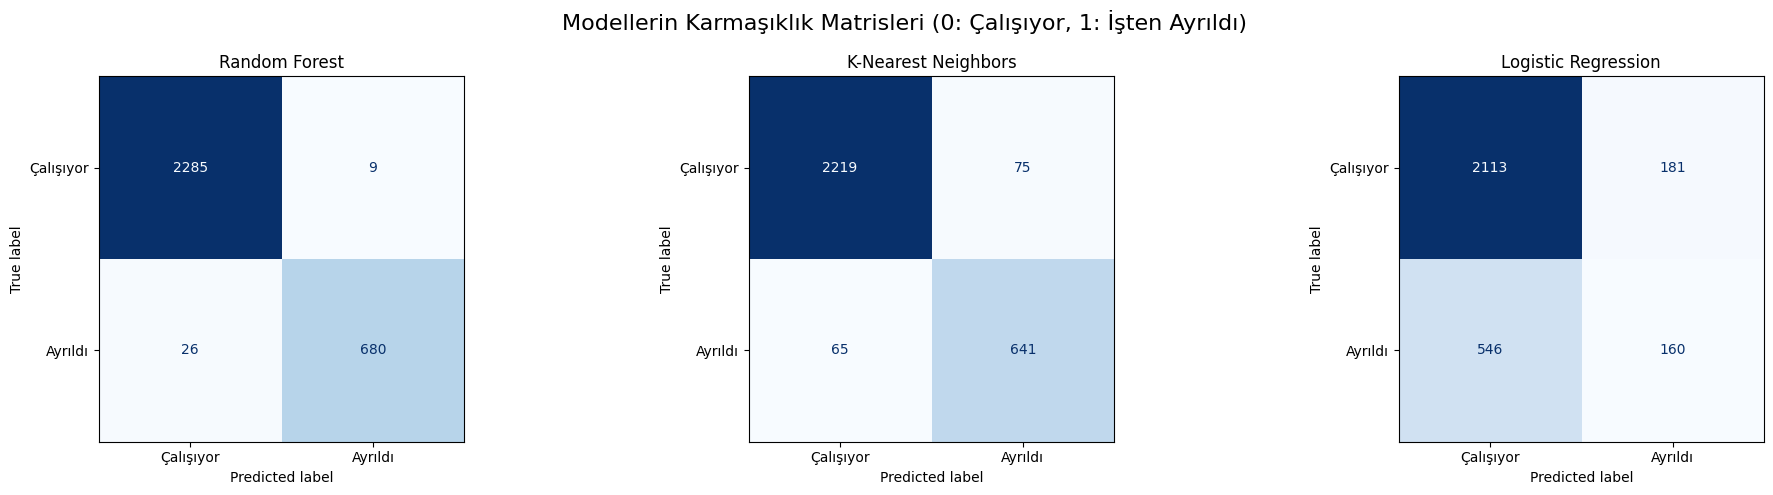

/tmp/ipykernel_14118/371028461.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='coolwarm')


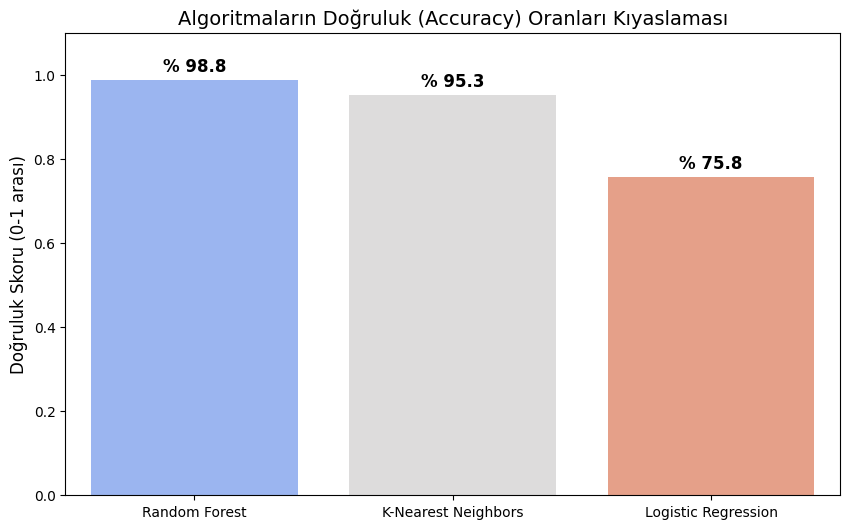

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# 1. VERİYİ OKU VE HAZIRLA
df = pd.read_csv('HR_comma_sep.csv')

# Kategorik metinleri (Maaş seviyesi, Departman vb.) sayılara dönüştür
le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

# Hedef değişken (left: 0 veya 1) ve bağımsız değişkenleri ayır
X = df.drop('left', axis=1)
y = df['left']

# Veriyi %80 Eğitim, %20 Test olarak böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modellerin daha yüksek başarı vermesi için verileri ölçeklendir
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. MODELLERİ TANIMLA
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(random_state=42)
}

results = {}

# Karmaşıklık Matrisleri için Grafik Alanı (1 satır, 3 sütun)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Modellerin Karmaşıklık Matrisleri (0: Çalışıyor, 1: İşten Ayrıldı)', fontsize=16)

# 3. MODELLERİ EĞİT, TEST ET VE RAPORLA
for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train) # Eğit
    y_pred = model.predict(X_test) # Test et

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    # Yazılı Raporlar 
    print(f"\n{'='*40}")
    print(f"--- {name} Performans Raporu ---")
    print(classification_report(y_test, y_pred))
    print(f"Doğruluk (Accuracy): {acc:.4f}")

    # Karmaşıklık Matrisini Çizdir
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Çalışıyor', 'Ayrıldı'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

# 4. ALGORİTMA KIYASLAMA GRAFİĞİ 
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='coolwarm')
plt.ylim(0, 1.1)
plt.title('Algoritmaların Doğruluk (Accuracy) Oranları Kıyaslaması', fontsize=14)
plt.ylabel('Doğruluk Skoru (0-1 arası)', fontsize=12)

# Barların üzerine yüzdeleri yazdıralım
for j, v in enumerate(results.values()):
    plt.text(j, v + 0.02, f"% {v*100:.1f}", ha='center', fontweight='bold', fontsize=12)

plt.show()

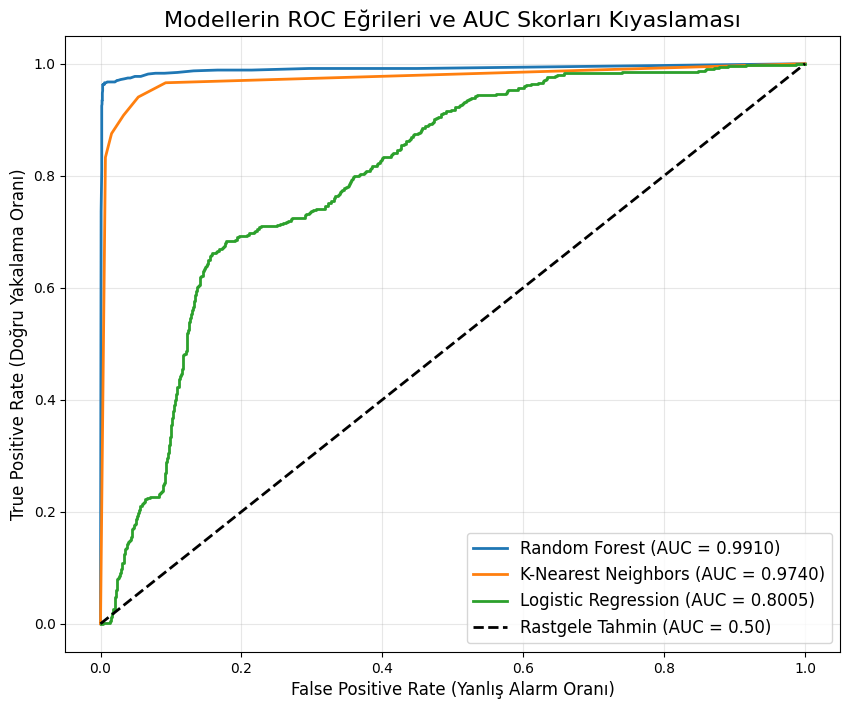

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Grafiğin boyutunu ayarlayalım
plt.figure(figsize=(10, 8))

# Her bir model için eğriyi hesapla ve çiz
for name, model in models.items():
    # Modellerin sınıf 1 (İşten Ayrıldı) için verdiği "olasılık" değerlerini alıyoruz
    y_prob = model.predict_proba(X_test)[:, 1]

    # FPR (False Positive Rate) ve TPR (True Positive Rate) değerlerini hesapla
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Eğrinin altında kalan alanı (AUC - Area Under Curve) hesapla
    auc_score = roc_auc_score(y_test, y_prob)

    # Eğriyi grafiğe ekle
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc_score:.4f})')

# Ortadaki rastgele tahmin çizgisini (şans çizgisi) ekleyelim
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Rastgele Tahmin (AUC = 0.50)')

# Grafiği isimlendir ve süsle
plt.xlabel('False Positive Rate (Yanlış Alarm Oranı)', fontsize=12)
plt.ylabel('True Positive Rate (Doğru Yakalama Oranı)', fontsize=12)
plt.title('Modellerin ROC Eğrileri ve AUC Skorları Kıyaslaması', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.show()